# Hysplit

Hysplit, or the Hybrid Single=Particle Lagrangian Integrated Trajectory model, computes air particle trajectories of various pollutants and particles, incorporating precise meteorlogical data from NOAA.o

This software has an incredible amount of granularity. To limit the complexity of the initial workflow, we'll walk through a model with two types of particles. Attached below is the documentation for HYSPLIT. Much of the model assumes you will be using their rudimentary GUI, but i recommend focus on the CONTROL file documentation starting on <b>pages 23-26 & 90-98</b>.

[Click Here For Documentation](https://www.arl.noaa.gov/documents/reports/hysplit_user_guide.pdf)

#### Meteorological data

Hysplit uses a unique format for its data. [Attached is a link](https://www.ready.noaa.gov/HYSPLIT_data2arl.php) to Hysplit's documentation involving this file format. The majority of the convertions in the library are functional, but we advice careful reading of this text.

In [1]:
import subprocess
import IPython
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from bokeh.plotting import *
from bokeh.models import LinearColorMapper, HoverTool
from bokeh.transform import linear_cmap, log_cmap
from pyproj import Transformer

### Toggle this flag to remove extra files to reduce clutter.

In [2]:
cleanup = False

### To begin, we must set up some basic parameters.

This includes choosing computational model configurations as well as particle amounts.

<i> Note that there are situations where NUMPAR can (and should) exceed MAXPAR </i>. This is because the actual particle release rate
is computed by dividing NUMPAR by the number of sources, pollutants, and release hours.

In [3]:
#Select initial model config (G = Gaussian, TH = Top-Hat, H = horizontal, V = vertical): 0 = 3D particle H and V (recommended), 1 = G-H and TH V puff
#2 = TH-H and V puff, 3 = G-H puff and V particle distribution, 5 = TH-H puff and V particle distribution
init = 0

#Select vertical turbulence computational model 1 = Beljaars/Holtslag and Betchov/Yaglom 2 = Kanthar/Clayson (DEFAULT) 
# 3 = TKE field from the input meteorology data file 4 = Measured velocity variances from the input meteorology 5 = Hanna
v_turb = 2

#Selecr horizontal turbulence computational model 0 = In proportion to the vertical turbulence (DEFAULT)
#1 = Computed from the velocity deformation
h_turb = 0

#Set defaults for input height: 0 = relative to terrain height of meteorological model (AGL), 
# 1 = subtract the local terrain height from source input heights (relative to mean sea level/MSL)
height = 1

#Set total particles released during each cycle (inits 0,3,4). Only one puff per cycle in inits 1 & 2
numpar = 32000

#Maximum particles of multiple release cycles (entire sim)
maxpar = 50000

#Set timestep to dump particle information, as well as interval to print. Refer to hysplit manual page 236-7 for complete information
ndump = 14

ncycles = 0

#Set particle output file name
outfile = "PARDUMP_volcano"

### Below, please set timing and spacial parameters.

The start date, start times for the particles, and runtime of the simulation should be entered below.

Additionally, latitude/longitude, as well as the bounds of the ash column (masl), along with the grid structure itself

In [4]:
#Set start date in year month day hour format
start_date = "10 02 11 16"

#Set number of source locations
num_source = 2

#Set volcano lat and long, as well as ash column height (in meters above mean sea level)
vol_height = "16.72 -62.18 915"

#Set vol lat and long of bottom of ash colun
vol_bottom = "16.72 -62.18 15200"

#total runtime hours
total_hours = 19

#Toggle using vertical velocity of model vs calc (0 vs 1)
vert_vel = 0

#Set top of model domain (m-msl)
domain_top = 32000

#Number of input data grids
num_grids = 1

#Set directory, filename
dir, filename = "./", "gdas_042.bin"

#Set number of pollutants
num_pol = 2

#For each pollutant, set identifier, emission rate, hours of emission, and release start time in (yy mm dd hh mm) format
id1, emiss1, hrs1, start_time1 = "par1", 9889459.98900167, 1, "10 02 11 16 35"
id2, emiss2, hrs2, start_time2 = "par2", 82824227.407889 , 1, "10 02 11 16 35"

### Specify grid and particle information

Now that the stats for the pollutants and volcano are entered, we can specify grid details, as well as some additional particle information.

In [5]:
#Set number of concentration grids
num_conc_grids = 1

#Set concentration grid center lat and long
conc_lat_long = "16.72 -62.18"

#Set spacing between nodes in sampling grid (lat long degrees)
spacing = "0.2 0.2"

#Set span in degrees (plume cutoff in lat long)
span = "90.0 180.0"

#Enter grid directory output and name
grid_dir, grid_filename = "./", "cdump_volcano"

#Set number of vertical concentration levels
vert_conc = 1

#Set height of level
vert_height = 18000

#Set sampling start and stop time (all zeros for stop for default. Refer to docs for further description)
samp_start, samp_stop = "10 02 11 17 00", "00 00 00 00 00"

#Set sampling interval (type, hour, minute)
samp_ival = "0 1 0" 

#Set number of depositing pollutants
num_depositing = 2

#Set each particle's diameter (um), density (g/cc), and shape
particle_def1 = "0.6 2.5 1.0"
particle_def2 = "2.0 2.5 1.0"

#Set each particle's Deposition velocity (m/s), Pollutant molecular weight (Gram/Mole), Surface Reactivity Ratio,
#Diffusivity Ratio, andEffective Henry's Constant

dry_dep_vals1 = "0.0 0.0 0.0 0.0 0.0"
dry_dep_vals2 = "0.0 0.0 0.0 0.0 0.0"

#Set wet removal values (Actual Henry's constant, In-cloud (GT 1 =L/L; LT 1 =1/s), Below-cloud (1/s)
wet_removal1 = "0.0 0.0 0.0"
wet_removal2 = "0.0 0.0 0.0"

#Set radioactive half-life in days (0 if stable/no decay)
decay1 = 0
decay2 = 0

#Set pollutant resuspension rate. Requires a deposition grid for nonzero values
resuspension1 = 0.0
resuspension2 = 0.0 


### The setup below allows for larger changes to the model configuration.

In [6]:
setup = f""" &SETUP
 tratio = 0.75,
 delt = 0.0,
 initd = {init},
 kpuff = 0,
 khmax = 9999,
 khinp = 0,
 numpar =  {numpar},
 maxpar = {maxpar},
 nbptyp = 1,
 qcycle = 0.0,
 efile = '',
 k10m = 1,
 kdef = {h_turb},
 krand =  2,
 kzmix = 0,
 kbls = 1,
 kblt =  {v_turb},
 isot = -99,
 idsp =  1,
 wvert = .TRUE.,
 plrise =  1,
 area =  0,
 vscale = 200.0,
 vscales =   5.0,
 vscaleu = 200.0,
 hscale = 10800.0,
 capemin =   -1.0,
 tkemin =  0.001000000,
 uratio =  5.873300076,
 tvmix = 1.00,
 tkerd = 0.18,
 tkern = 0.18,
 kmix0 = 150,
 kmixd = 0,
 ninit = 1,
 ndump = {ndump},
 ncycl =  {ncycles},
 pinbc = 'PARINBC',
 pinpf = 'PARINIT',
 poutf = '{outfile}',
 messg = 'MESSAGE',
 vdist = 'VMSDIST',
 mgmin = 10,
 conage = 24,
 gemage = 48,
 kmsl = {height},
 kwet = 1,
 ichem = 0,
 cpack = 1,
 cmass = 0,
 kspl = 1,
 krnd = 6,
 frhmax = 3.00,
 splitf = 1.00,
 frhs = 1.00,
 frvs = 0.01,
 frts = 0.10,
 dxf = 1.00,
 dyf = 1.00,
 dzf = 0.01,
 /
"""
with open("SETUP.volcano",'w') as f:
    f.write(setup)

### Finish model setup and run

Run the next two cells to finish setting up the input parameters and run Hysplit!

In [7]:
control = f"""{start_date}			#STARTING YEAR MONTH DAY HOUR
{num_source}                     #NUMBER OF SOURCE LOCATIONS
{vol_height}       #VOLCANO LATITUDE LONGITUDE ASH COLUMN HEIGHT(m-msl)
{vol_bottom}            #VOLCANO LATITUDE LONGITUDE ASH COLUMN BOTTOM (m-msl)
{total_hours}                     #TOTAL RUN TIME (hours)
{vert_vel}                    #USE MODEL VERTICAL VELOCITY
{domain_top}               #TOP OF MODEL DOMAIN (m-agl)
{num_grids}                #NUMBER OF INPUT DATA GRIDS
{dir}
{filename}
{num_pol}			#NUMBER OF DIFFERENT POLLUTANTS
{id1}                 #POLLUTANT IDENTIFICATION
{emiss1}                  #EMISSION RATE (per hour)
{hrs1}                    #HOURS OF EMISSION
{start_time1}         #RELEASE START TIME:YEAR MONTH DAY HOUR MINUTE
{id2}                 #POLLUTANT IDENTIFICATION
{emiss2}                  #EMISSION RATE (per hour)
{hrs2}                    #HOURS OF EMISSION
{start_time2}          #RELEASE START TIME:YEAR MONTH DAY HOUR MINUTE
{num_conc_grids}                        #NUMBER OF CONCENTRATION GRIDS
{conc_lat_long}             #CONC GRID CENTER LATITUDE LONGITUDE
{spacing}                #CONC GRID SPACING (degrees) LATITUDE LONGITUDE
{span}                  #CONC GRID SPAN (degrees) LATITUDE LONGITUDE
{grid_dir}
{grid_filename}
{vert_conc}                             #NUMBER OF VERTICAL CONCENTRATION LEVELS
{vert_height}                        #HEIGHT OF EACH CONCENTRATION LEVEL (m-msl)
{samp_start}           #SAMPLING START TIME:YEAR MONTH DAY HOUR MINUTE
{samp_stop}          #SAMPLING STOP TIME:YEAR MONTH DAY HOUR MINUTE
{samp_ival}                         #SAMPLING INTERVAL: TYPE HOUR MINUTE
{num_depositing}                    #NUMBER OF DEPOSITING POLLUTANTS
{particle_def1}     #PARTICLE:DIAMETER (um), DENSITY (g/cc), SHAPE
{dry_dep_vals1}    #DEP VEL (m/s), MW (g/Mole), SFC REACT. RATIO, DIFFUSIVITY RATIO, HENRY'S CONSTANT
{wet_removal1}   #WET REMOVAL: HENRY'S (Molar/atm), IN-CLOUD (L/L), BELOW-CLOUD (1/s)
{decay1}                        #RADIOACTIVE DECAY HALF-LIFE (days)
{resuspension1}                      #POLLUTANT RESUSPENSION (1/m)
{particle_def2}    #PARTICLE:DIAMETER (um), DENSITY (g/cc), SHAPE
{dry_dep_vals2}    #DEP VEL (m/s), MW (g/Mole), SFC REACT. RATIO, DIFFUSIVITY RATIO, HENRY'S CONSTANT
{wet_removal2}   #WET REMOVAL: HENRY'S (Molar/atm), IN-CLOUD (L/L), BELOW-CLOUD (1/s)
{decay2}                        #RADIOACTIVE DECAY HALF-LIFE (days)
{resuspension2}                      #POLLUTANT RESUSPENSION (1/m)"""
f = open("CONTROL.volcano",'w')
f.write(control)
f.close()

In [8]:
subprocess.run("./hycs_std volcano",shell=True)

 HYSPLIT - Initialization volcano
 HYSPLIT version: hysplit.v5.2.2
 Last Changed Date: 2022-06-22
  NOTICE   main: using namelist file - SETUP.volcano
 Calculation Started ... please be patient
 Percent complete:   5.3
 Percent complete:  10.5
 Percent complete:  15.8
 Percent complete:  21.1
 Percent complete:  26.3
 Percent complete:  31.6
 Percent complete:  36.8
 Percent complete:  42.1
 Percent complete:  47.4
 Percent complete:  52.6
 Percent complete:  57.9
 Percent complete:  63.2
 Percent complete:  68.4
 Percent complete:  73.7
 Percent complete:  78.9
 Percent complete:  84.2
 Percent complete:  89.5
 Percent complete:  94.7
 Percent complete: 100.0
 Complete Hysplit


CompletedProcess(args='./hycs_std volcano', returncode=0)

### Visualization 

Now that we have successfully run the simulation, three options are possible. 

First, using the output binary with the provided HYSPLIT executables can give us a the model output displayed as an image. 

In [9]:
subprocess.run("./parxplot -iPARDUMP_volcano -pvolcano -k1 -m1 -z90",shell=True)
subprocess.run("mv parxplot.volcano parxplot_volcano.ps",shell=True)
subprocess.run("gs -dTextAlphaBits=4 -dGraphicsAlphaBits=4 -dNOPAUSE -dSAFER -sDEVICE=pnmraw -q -sOutputFile=- parxplot_volcano.ps  -c quit | convert -trim +repage +adjoin - GIF:parxplot_volcano.gif",shell=True)

 Complete Parxplot


CompletedProcess(args='gs -dTextAlphaBits=4 -dGraphicsAlphaBits=4 -dNOPAUSE -dSAFER -sDEVICE=pnmraw -q -sOutputFile=- parxplot_volcano.ps  -c quit | convert -trim +repage +adjoin - GIF:parxplot_volcano.gif', returncode=0)

In [10]:
subprocess.run("./par2asc -iPARDUMP_volcano",shell=True)
coords = []
with open("./PARDUMP.txt") as pardump:
    particles = pardump.read()
    s =  ['Header'+e for e in particles.split('Header') if e]
    if len(s) != 1:
        s = s[1:]

### Select Timestamp

Depending on how the user chose to set output intervals, there may be multiple moments in time to visualize. Please select one below

In [11]:
print('There are',len(s),"timestamps to visualize ( 1 -",len(s),"), please choose one:")

There are 1 timestamps to visualize ( 1 - 1 ), please choose one:


In [12]:
timestamp = 1

In [13]:
choice = s[timestamp-1]
choice = choice.split("\n")
for num,line in enumerate(choice):
    if num % 3 == 0 and num > 3:
        split = [float(val) for val in line.split()]
        coords.append(split)
df = pd.DataFrame(coords)
len(s)

1

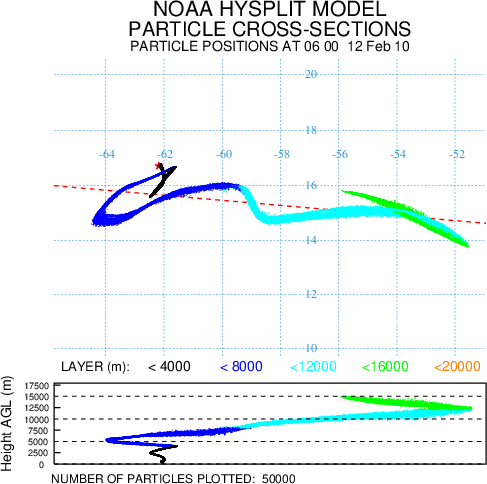

In [14]:
from PIL import Image
from IPython.display import display

if len(s) == 1:
    img = Image.open('parxplot_volcano.gif')
    display(img)
else:
    img = Image.open("".join(("./parxplot_volcano-",str(timestamp),".gif")))
    display(img)

### Second Visualization

Using traditional Matplotlib tools mixed with Cartopy, you can create a near identical plot with additional detail and better contrast.

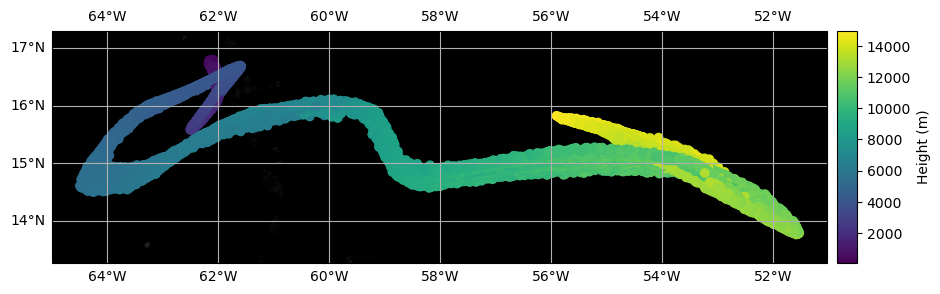

In [15]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.io.img_tiles import GoogleTiles

minx, maxx = min(df[1]), max(df[1])
miny, maxy = min(df[0]), max(df[0])
fig = plt.figure(figsize=(10,10))
tiler = GoogleTiles(style='terrain')
mercator = tiler.crs
ax = plt.axes(projection=mercator) #use a mercator map projection

ax.set_extent((minx-.5,maxx+.5, miny-.5,maxy+.5))

# #Increase the zoom level for more resolution on the terrain
zoom = 9
ax.add_image(tiler, zoom)
im = plt.scatter(df[1],df[0],c=df[2],transform=ccrs.PlateCarree())
cax = fig.add_axes([ax.get_position().x1+0.01,
                    ax.get_position().y0,
                    0.02,
                    ax.get_position().height])
 
# Plot vertical colorbar
cb = plt.colorbar(im, cax=cax)
cb.set_label("Height (m)")
gl = ax.gridlines(draw_labels=True)
gl.right_labels = False

### Third Visualization

Using Bokeh, a highly versatile interactive visualization library, you can get pinpoint accurate data points and zoom in/out on the data as needed.

In [16]:
colors = [
    "#%02x%02x%02x" % (int(r), int(g), int(b)) for r, g, b, _ in 255*mpl.cm.viridis(mpl.colors.Normalize()(df[2]))
]

transf = Transformer.from_crs("epsg:4326","epsg:3857")

latlong = transf.transform(df[0],df[1])

source = ColumnDataSource(data=dict(
    x=list(latlong[0]),
    y=list(latlong[1]),
    foo=list(df[2]),
    long=list(df[1]),
    lat=list(df[0])
))
mapper = linear_cmap(field_name='foo', palette='Viridis256', low=min(df[2]), high=max(df[2]))
tooltips = [
            ('height', '@foo'),
            ('Latitude','@lat'),
            ('Longitude','@long')
        ]
p = figure(x_axis_type="mercator", y_axis_type="mercator",tooltips=tooltips,title="Particle Map")
p.add_tile("Esri World Imagery")
p.scatter('x','y',size=5,source=source, line_color=mapper,color=mapper)
output_notebook()
show(p)

Loading BokehJS ...

### Second Set of visualizations

Above, you represented three ways of viewing the height of the ash.

Below, you will display the concentration of the ash along this path. Here, we will simply show Hysplit's built in display capabilities. 

In [17]:
subprocess.run("./concplot -icdump_volcano -omassl.volcano -m0 -d2 -c1 -z75 -n14:14 -a0 -k2 -s0 -l115 -ug  ${dashx} -pvolcano -qdatem_loc.txt",shell=True)
subprocess.run("mv massl.volcano massl.volcano.ps",shell=True)
subprocess.run("gs -dTextAlphaBits=4 -dGraphicsAlphaBits=4 -dNOPAUSE -dSAFER -sDEVICE=pnmraw -q -sOutputFile=- massl.volcano.ps  -c quit | convert -trim +repage +adjoin - GIF:massl.volcano.gif",shell=True)

 Started Concentration Drawing
 HYSPLIT version: hysplit.v5.2.2
 Last Changed Date: 2022-06-22
 NOTICE changing -d2 to -d1 since single layer
 Multiple pollutant species in file
           1  - par1
           2  - par2
 Finished map:           14
 Complete Concplot:           1  time periods
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  

CompletedProcess(args='gs -dTextAlphaBits=4 -dGraphicsAlphaBits=4 -dNOPAUSE -dSAFER -sDEVICE=pnmraw -q -sOutputFile=- massl.volcano.ps  -c quit | convert -trim +repage +adjoin - GIF:massl.volcano.gif', returncode=0)

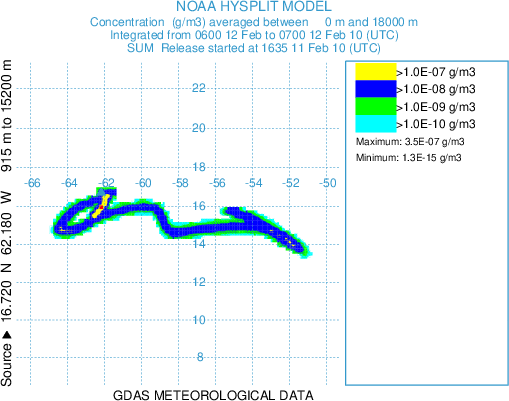

In [18]:
IPython.display.Image("massl.volcano.gif")

In [ ]:
if cleanup:
    subprocess.run("rm *.ps", shell=True)
    os.remove("CON2ASC.OUT")